In [66]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [67]:
df = pd.read_csv("weather_dirty_dataset.csv")

In [68]:
'''
to change data type
1.mintemp,maxtemp,rainfall to float

'''
df.isnull().sum()

ObservationID     0
Date              0
Location          0
MinTemp           0
MaxTemp           0
Rainfall          0
Evaporation      82
Sunshine         80
WindGustDir      81
WindGustSpeed     0
WindDir9am        0
WindDir3pm        0
WindSpeed9am      0
WindSpeed3pm      0
Humidity9am       0
Humidity3pm       0
Pressure9am      81
Pressure3pm      81
Cloud9am         82
Cloud3pm         80
Temp9am           0
Temp3pm           0
RainToday         0
UVIndex           0
Visibility_km     0
DewPoint         81
RainTomorrow      0
dtype: int64

In [69]:
df.dtypes

ObservationID     object
Date              object
Location          object
MinTemp           object
MaxTemp           object
Rainfall          object
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed      int64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am        int64
Humidity3pm        int64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
UVIndex            int64
Visibility_km    float64
DewPoint         float64
RainTomorrow      object
dtype: object

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ObservationID  1015 non-null   object 
 1   Date           1015 non-null   object 
 2   Location       1015 non-null   object 
 3   MinTemp        1015 non-null   object 
 4   MaxTemp        1015 non-null   object 
 5   Rainfall       1015 non-null   object 
 6   Evaporation    933 non-null    float64
 7   Sunshine       935 non-null    float64
 8   WindGustDir    934 non-null    object 
 9   WindGustSpeed  1015 non-null   int64  
 10  WindDir9am     1015 non-null   object 
 11  WindDir3pm     1015 non-null   object 
 12  WindSpeed9am   1015 non-null   float64
 13  WindSpeed3pm   1015 non-null   float64
 14  Humidity9am    1015 non-null   int64  
 15  Humidity3pm    1015 non-null   int64  
 16  Pressure9am    934 non-null    float64
 17  Pressure3pm    934 non-null    float64
 18  Cloud9am

In [71]:
def float_maker(x):
    if pd.isna(x) or x=="": 
        return np.nan
    x= str(x) 
    x= x.replace("Â°C","").replace("°C","").replace("mm","")
    return float(x)

In [72]:
for col in ["MinTemp","MaxTemp","Rainfall"]:
    df[col] = df[col].apply(float_maker)

In [73]:
df["MaxTemp"].iloc[108]

np.float64(26.7)

In [74]:
df.dtypes

ObservationID     object
Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed      int64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am        int64
Humidity3pm        int64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
UVIndex            int64
Visibility_km    float64
DewPoint         float64
RainTomorrow      object
dtype: object

In [75]:
df.isnull().sum()

ObservationID     0
Date              0
Location          0
MinTemp           0
MaxTemp           0
Rainfall          0
Evaporation      82
Sunshine         80
WindGustDir      81
WindGustSpeed     0
WindDir9am        0
WindDir3pm        0
WindSpeed9am      0
WindSpeed3pm      0
Humidity9am       0
Humidity3pm       0
Pressure9am      81
Pressure3pm      81
Cloud9am         82
Cloud3pm         80
Temp9am           0
Temp3pm           0
RainToday         0
UVIndex           0
Visibility_km     0
DewPoint         81
RainTomorrow      0
dtype: int64

In [76]:
df[["MinTemp","MaxTemp"]].iloc[100:130]

,MinTemp,MaxTemp
100,24.2,36.8
101,22.1,33.8
102,9.4,200.0
103,-200.0,26.8
104,16.2,24.1
105,11.5,24.3
106,13.5,-50.0
107,11.2,24.3
108,16.3,26.7
109,24.6,27.5


<Axes: ylabel='MinTemp'>

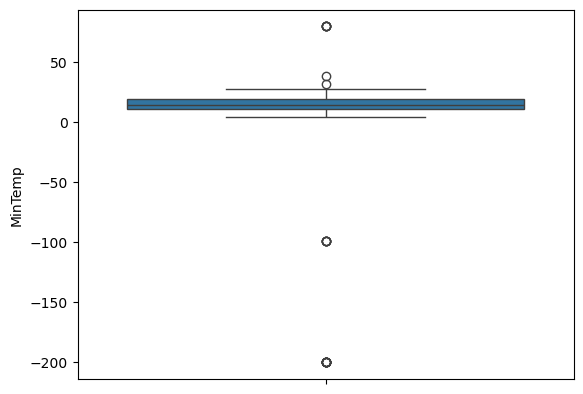

In [77]:
sns.boxplot(df["MinTemp"])

In [78]:
df["MinTemp"].describe()

count    1015.000000
mean       12.684729
std        23.733474
min      -200.000000
25%        10.800000
50%        14.500000
75%        19.050000
max        80.000000
Name: MinTemp, dtype: float64

In [79]:
def range_maker(x): 
    q1 = df[x].quantile(0.25)
    q3 = df[x].quantile(0.75)

    iqr = q3 - q1 

    lower = q1 - 1.5*iqr 
    upper = q3 + 1.5*iqr 

    ran = [lower,upper]

    df.loc[ ( (df[x]<lower ) | (df[x]>upper ) ) ,x] = np.nan

In [82]:
range_maker("MinTemp")

<Axes: ylabel='MinTemp'>

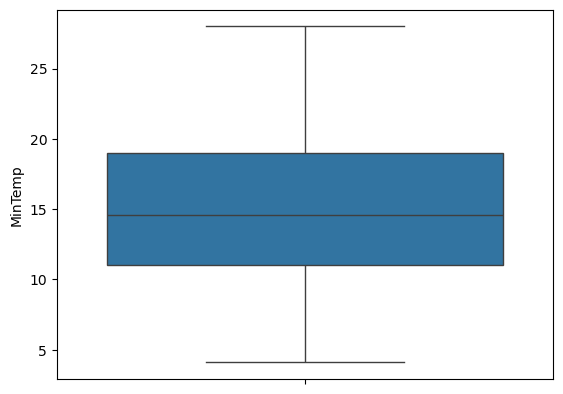

In [83]:
sns.boxplot(df["MinTemp"])

<Axes: ylabel='MaxTemp'>

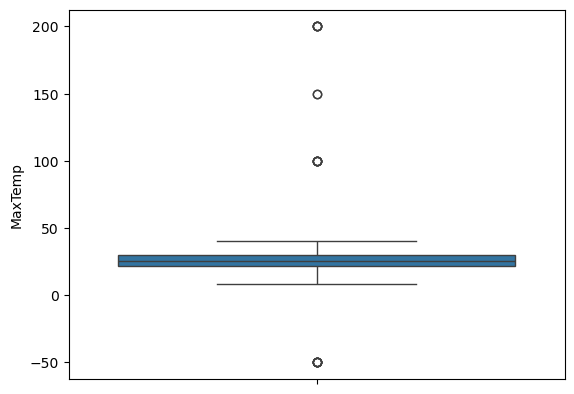

In [84]:
sns.boxplot(df["MaxTemp"])

In [87]:
range_maker("MaxTemp")

<Axes: ylabel='MaxTemp'>

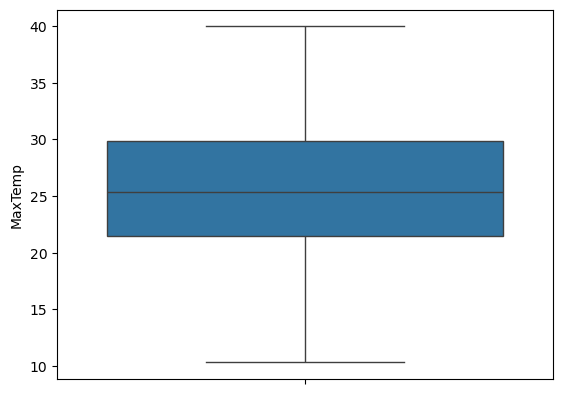

In [88]:
sns.boxplot(df["MaxTemp"])

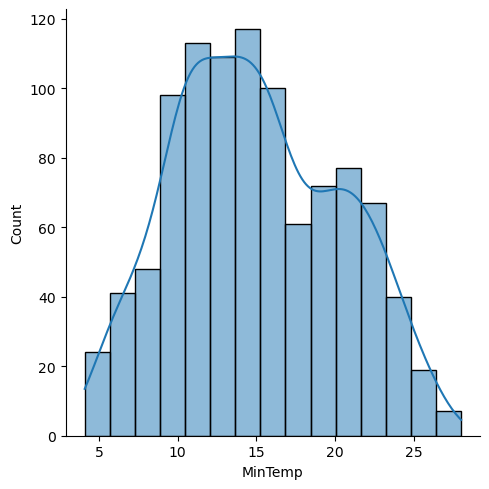

In [89]:
sns.displot(df["MinTemp"],kde=True)

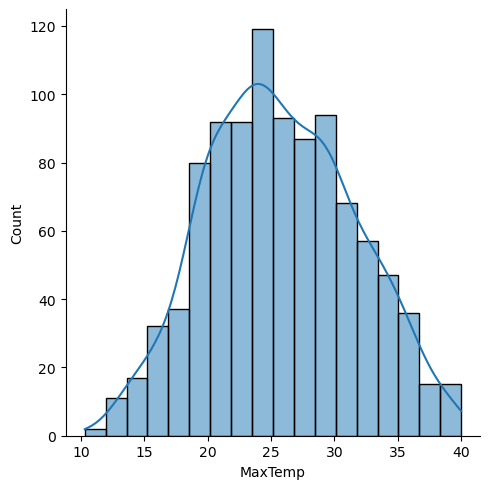

In [90]:
sns.displot(df["MaxTemp"],kde=True)

In [91]:
print(df["MinTemp"].skew())
print(df["MaxTemp"].skew())

0.18774466288952793
0.10835578064048412


In [92]:
df["MinTemp"] = df["MinTemp"].fillna(df["MinTemp"].median())
df["MaxTemp"] = df["MaxTemp"].fillna(df["MaxTemp"].mean())

In [93]:
print(df["MaxTemp"].skew())

0.10949097502732688


<Axes: ylabel='Rainfall'>

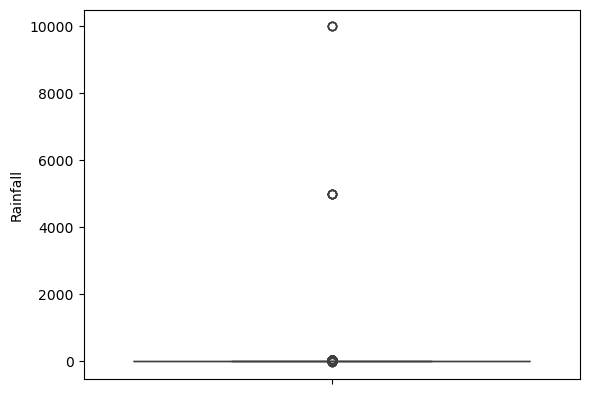

In [94]:
sns.boxplot(df["Rainfall"])

In [95]:
range_maker("Rainfall")

<Axes: ylabel='Rainfall'>

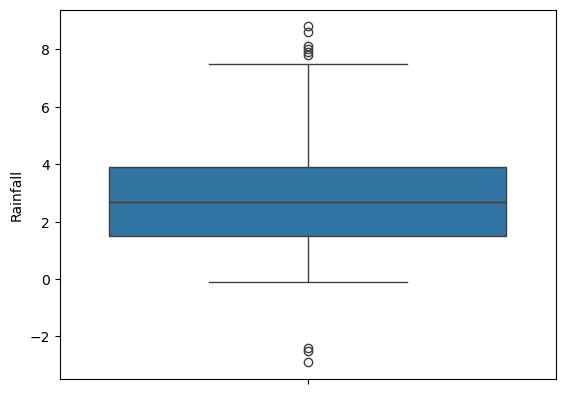

In [96]:
sns.boxplot(df["Rainfall"])

In [99]:
range_maker("Rainfall")

<Axes: ylabel='Rainfall'>

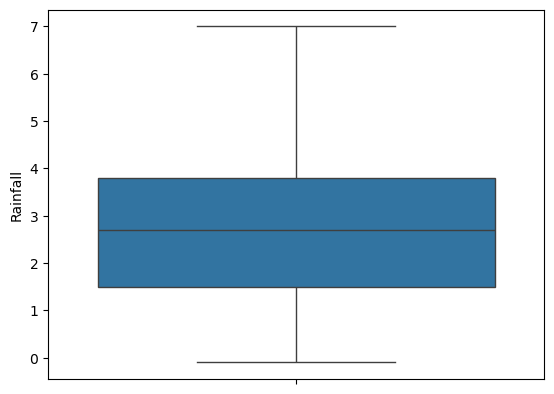

In [100]:
sns.boxplot(df["Rainfall"])

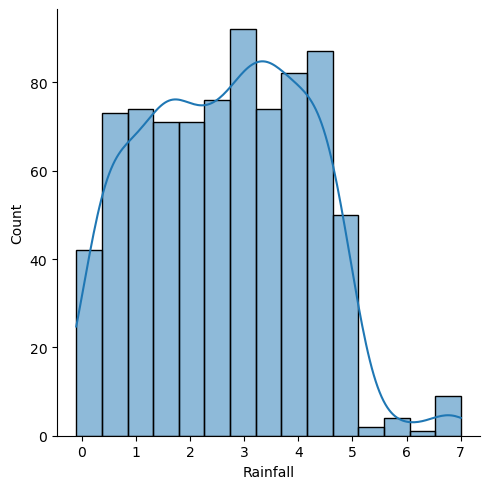

In [101]:
sns.displot(df["Rainfall"],kde=True)

In [102]:
df["Rainfall"].isnull().sum() 

np.int64(207)

In [103]:
print(df["Rainfall"].skew())

0.13121367587215926


In [104]:
df.isnull().sum()

ObservationID      0
Date               0
Location           0
MinTemp            0
MaxTemp            0
Rainfall         207
Evaporation       82
Sunshine          80
WindGustDir       81
WindGustSpeed      0
WindDir9am         0
WindDir3pm         0
WindSpeed9am       0
WindSpeed3pm       0
Humidity9am        0
Humidity3pm        0
Pressure9am       81
Pressure3pm       81
Cloud9am          82
Cloud3pm          80
Temp9am            0
Temp3pm            0
RainToday          0
UVIndex            0
Visibility_km      0
DewPoint          81
RainTomorrow       0
dtype: int64

<Axes: >

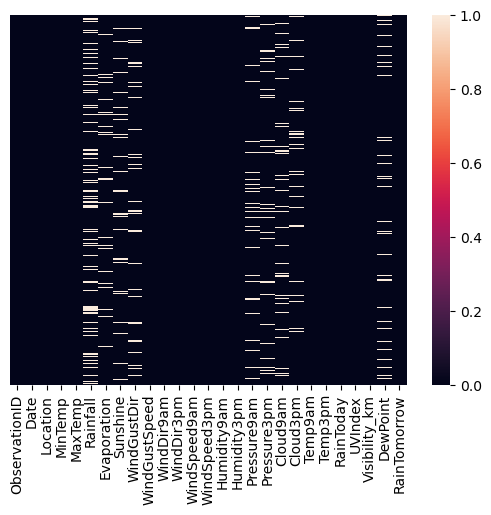

In [105]:
sns.heatmap(df.isnull(),yticklabels=False)

In [106]:
row_nulls = df.isnull().sum(axis=1)
print(row_nulls.value_counts().sort_index())

0    413
1    406
2    147
3     41
4      8
Name: count, dtype: int64


In [107]:
cols_check = ['Evaporation','Sunshine','WindGustDir','Pressure9am','Pressure3pm','Cloud9am','Cloud3pm']
df[cols_check].isnull().sum(axis=1).value_counts().sort_index()

0    568
1    344
2     87
3     15
4      1
Name: count, dtype: int64

In [108]:
df["Location"].unique()

array(['Adelaide', 'Perth', 'Melbourne', 'Newcastle', 'Darwin',
       'Canberra', 'Hobart', 'Townsville', 'Sydney', 'Cairns',
       'Wollongong', 'MELBOURNE', 'Brisbane', 'Adel@ide', 'Brisbone'],
      dtype=object)

In [109]:
titleize = lambda x: str(x).title()

In [110]:
df["Location"] = df["Location"].apply(titleize)

In [111]:
df["Location"].unique()

array(['Adelaide', 'Perth', 'Melbourne', 'Newcastle', 'Darwin',
       'Canberra', 'Hobart', 'Townsville', 'Sydney', 'Cairns',
       'Wollongong', 'Brisbane', 'Adel@Ide', 'Brisbone'], dtype=object)

In [112]:
df["Location"] = df["Location"].str.replace("Adel@Ide","Adelaide")

In [113]:
df["Location"].unique() 

array(['Adelaide', 'Perth', 'Melbourne', 'Newcastle', 'Darwin',
       'Canberra', 'Hobart', 'Townsville', 'Sydney', 'Cairns',
       'Wollongong', 'Brisbane', 'Brisbone'], dtype=object)

In [114]:
df["Rainfall"] = df.groupby('Location')["Rainfall"].transform(lambda x: x.fillna(x.median()))

In [115]:
df.dtypes

ObservationID     object
Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed      int64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am        int64
Humidity3pm        int64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
UVIndex            int64
Visibility_km    float64
DewPoint         float64
RainTomorrow      object
dtype: object

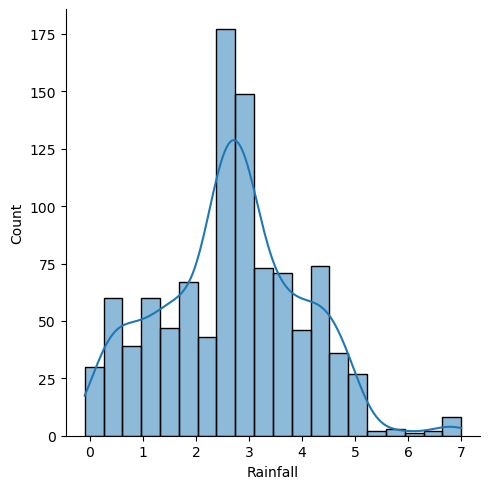

In [116]:
sns.displot(df["Rainfall"],kde=True)

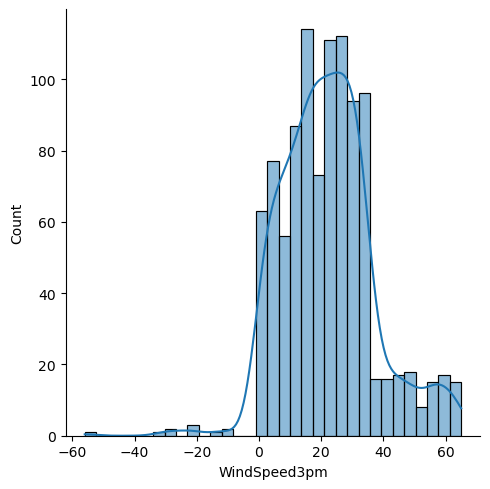

In [117]:
sns.displot(df["WindSpeed3pm"],kde=True)

<Axes: ylabel='WindSpeed3pm'>

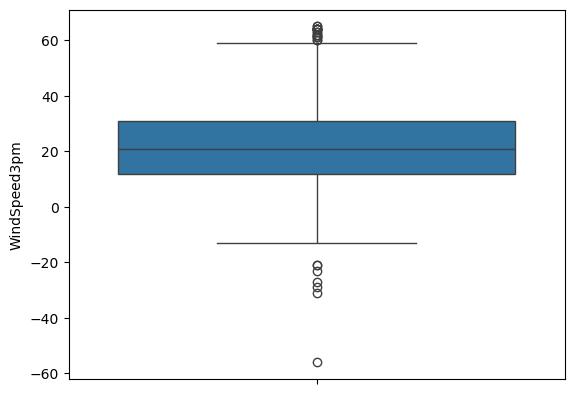

In [118]:
sns.boxplot(df["WindSpeed3pm"])

In [119]:
df["Pressure3pm"].isnull().sum()

np.int64(81)

In [120]:
numeric_cols = ['Evaporation','Sunshine','Pressure9am','Pressure3pm','Cloud9am','Cloud3pm','DewPoint',"WindGustSpeed","WindSpeed9am","WindSpeed3pm","Humidity9am","Humidity3pm","Temp9am","Temp3pm","UVIndex","Visibility_km"]

In [121]:
num_mean = ["Sunshine","Pressure9am","DewPoint","WindGustSpeed","Temp9am","Temp3pm" ]
num_med = ["Evaporation","Pressure3pm","Cloud9am","Cloud3pm","WindGustSpeed","WindSpeed9am","WindSpeed3pm","Humidity9am" ,"Humidity3pm","UVIndex","Visibility_km"]

In [130]:
df.loc[df["WindSpeed3pm"] < 0, "WindSpeed3pm"] = np.nan
df.loc[df["WindSpeed9am"] < 0, "WindSpeed9am"] = np.nan

In [129]:
for col in numeric_cols:
    range_maker(col)

In [131]:
for col in num_mean: 
    df[col] = df[col].fillna(df[col].mean())

In [132]:
for col in num_med:
    df[col] = df[col].fillna(df[col].median())

In [133]:
df["Pressure3pm"].isnull().sum()

np.int64(0)

<Axes: ylabel='Pressure3pm'>

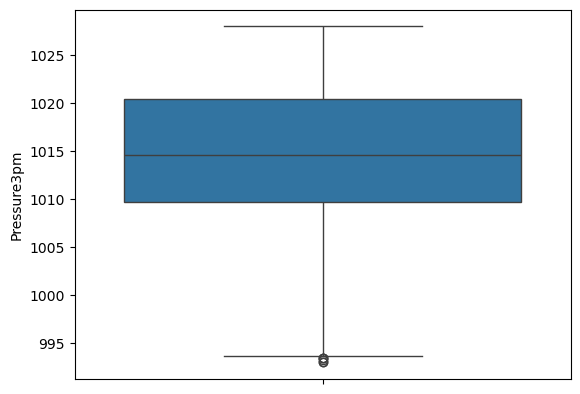

In [134]:
sns.boxplot(df["Pressure3pm"])

<Axes: >

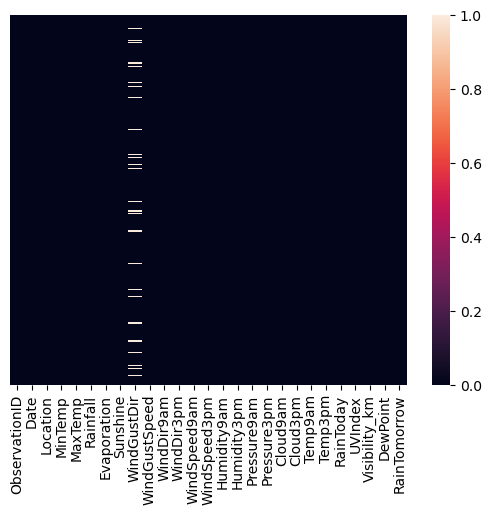

In [135]:
sns.heatmap(df.isnull(),yticklabels=False)

In [136]:
df["WindGustDir"] = df["WindGustDir"].fillna(df["WindGustDir"].mode()[0])

<Axes: >

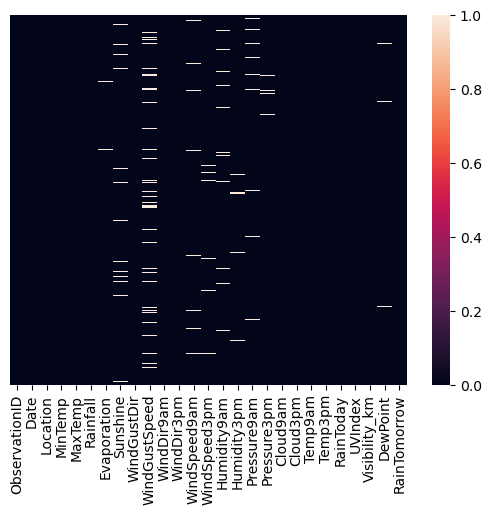

In [59]:
sns.heatmap(df.isnull(),yticklabels=False)

In [137]:
y = ["1","Y","TRUE","True"]
n = ["0","N","FALSE","False"]

In [138]:
df[["RainToday","RainTomorrow"]] = (
    df[["RainToday","RainTomorrow"]]
    .replace(y, "Yes")
    .replace(n, "No")
)

In [139]:
df[["RainToday","RainTomorrow"]] = (
    df[["RainToday","RainTomorrow"]]
    .apply(lambda col: col.str.strip().str.title())
)

In [140]:
df["RainTomorrow"].unique()

array(['Yes', 'No'], dtype=object)

In [141]:
print(repr(df["RainTomorrow"].iloc[0]))
print(len(str(df["RainTomorrow"].iloc[0])))

'Yes'
3


<Axes: >

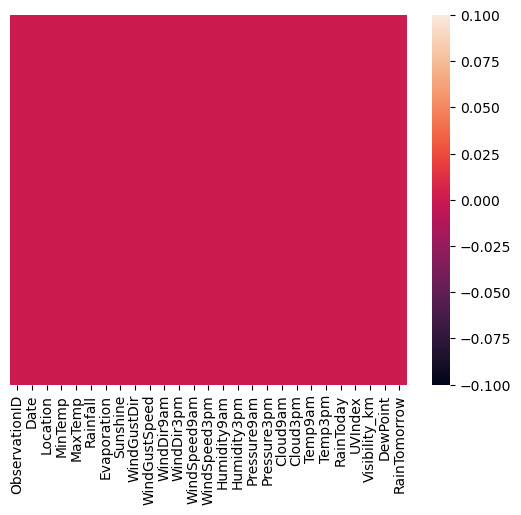

In [142]:
sns.heatmap(df.isnull(),yticklabels=False)

In [143]:
df.to_csv("Cleaned_Weather.csv")

In [148]:
from sklearn.preprocessing import MinMaxScaler , StandardScaler

cols_scale = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
    'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
    'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
    'Temp9am', 'Temp3pm', 'DewPoint', 'UVIndex', 'Visibility_km'
]

In [150]:
df_norm = df.copy()

scaler_norm = MinMaxScaler()

df_norm[cols_scale] = scaler_norm.fit_transform(df[cols_scale])

df_norm.to_csv("cleaned_weather_normalised.csv")

In [151]:
df_stdz = df.copy() 

scaler_stdz = StandardScaler() 

df_stdz[cols_scale] = scaler_stdz.fit_transform(df[cols_scale])

df_stdz.to_csv("cleaned_weather_standardized.csv")